In [15]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [16]:
import pandas as pd

# Define the file path
file_path = 'ecg_sleep_apnea_dataset.csv'

try:
    # Load the dataset
    df = pd.read_csv(file_path)
    
    # Display basic metadata
    print("--- Dataset Info ---")
    print(df.info())
    
    # Display the first 5 rows
    print("\n--- Head of Dataset ---")
    print(df.head())

except FileNotFoundError:
    print("Error: File not found. Please check if the dataset is correctly attached to your Kaggle kernel.")

--- Dataset Info ---
<class 'pandas.DataFrame'>
RangeIndex: 2660 entries, 0 to 2659
Columns: 2501 entries, 0 to Target
dtypes: float64(2500), str(1)
memory usage: 50.8 MB
None

--- Head of Dataset ---
          0         1         2         3         4         5         6  \
0  0.012976  0.022008  0.049401  0.007309  0.080700  0.084465  0.053040   
1  0.007665  0.011024  0.014001  0.115614  0.045236  0.053854  0.144119   
2  0.044957  0.028612  0.085881  0.018910  0.078694  0.103297  0.046348   
3 -0.011676  0.027831  0.029627  0.021658  0.068194  0.075705  0.095863   
4 -0.008188  0.001010 -0.009165  0.061274  0.087704  0.055419  0.120823   

          7         8         9  ...      2491      2492      2493      2494  \
0  0.110527  0.147975  0.158048  ... -0.086520 -0.076036 -0.073070 -0.075017   
1  0.093378  0.178889  0.133928  ... -0.590053 -0.585818 -0.504592 -0.412495   
2  0.148435  0.148251  0.140560  ... -0.663029 -0.596072 -0.501529 -0.432133   
3  0.123471  0.155526  0.150

Loading data...
Data Loaded: 2660 samples, 2500 signal time-steps.
Extracting interpretable physiological features...
Feature extraction complete.

--- Exploratory Data Analysis (Clinical Insights) ---
Calculating feature statistics by class...

Average Feature Values (Normal vs. Apnea):
Target_Label        Apnea     Normal
Mean_Amp         0.014614  -0.003385
Std_Dev_Amp      0.508033   0.495637
Max_Amp          1.018737   0.758414
Min_Amp         -1.117024  -0.761074
Skewness        -0.096282   0.010032
Kurtosis        -1.443925  -1.492623
RMS_Energy       0.508257   0.495660
RMSSD            0.119559   0.033592
Zero_Crossings  78.702763  31.890235
Generating individual feature distribution boxplots...
EDA complete. Analytics saved as 'feature_comparison_by_class.csv' and 'feature_distributions.png'.
Splitting data and training XGBoost Model...

--- 5-Fold Cross-Validation ---
Mean CV Accuracy: 96.92% (Std: ±3.70%)

--- Final Test Set Performance ---
Accuracy: 95.49%

Classification 

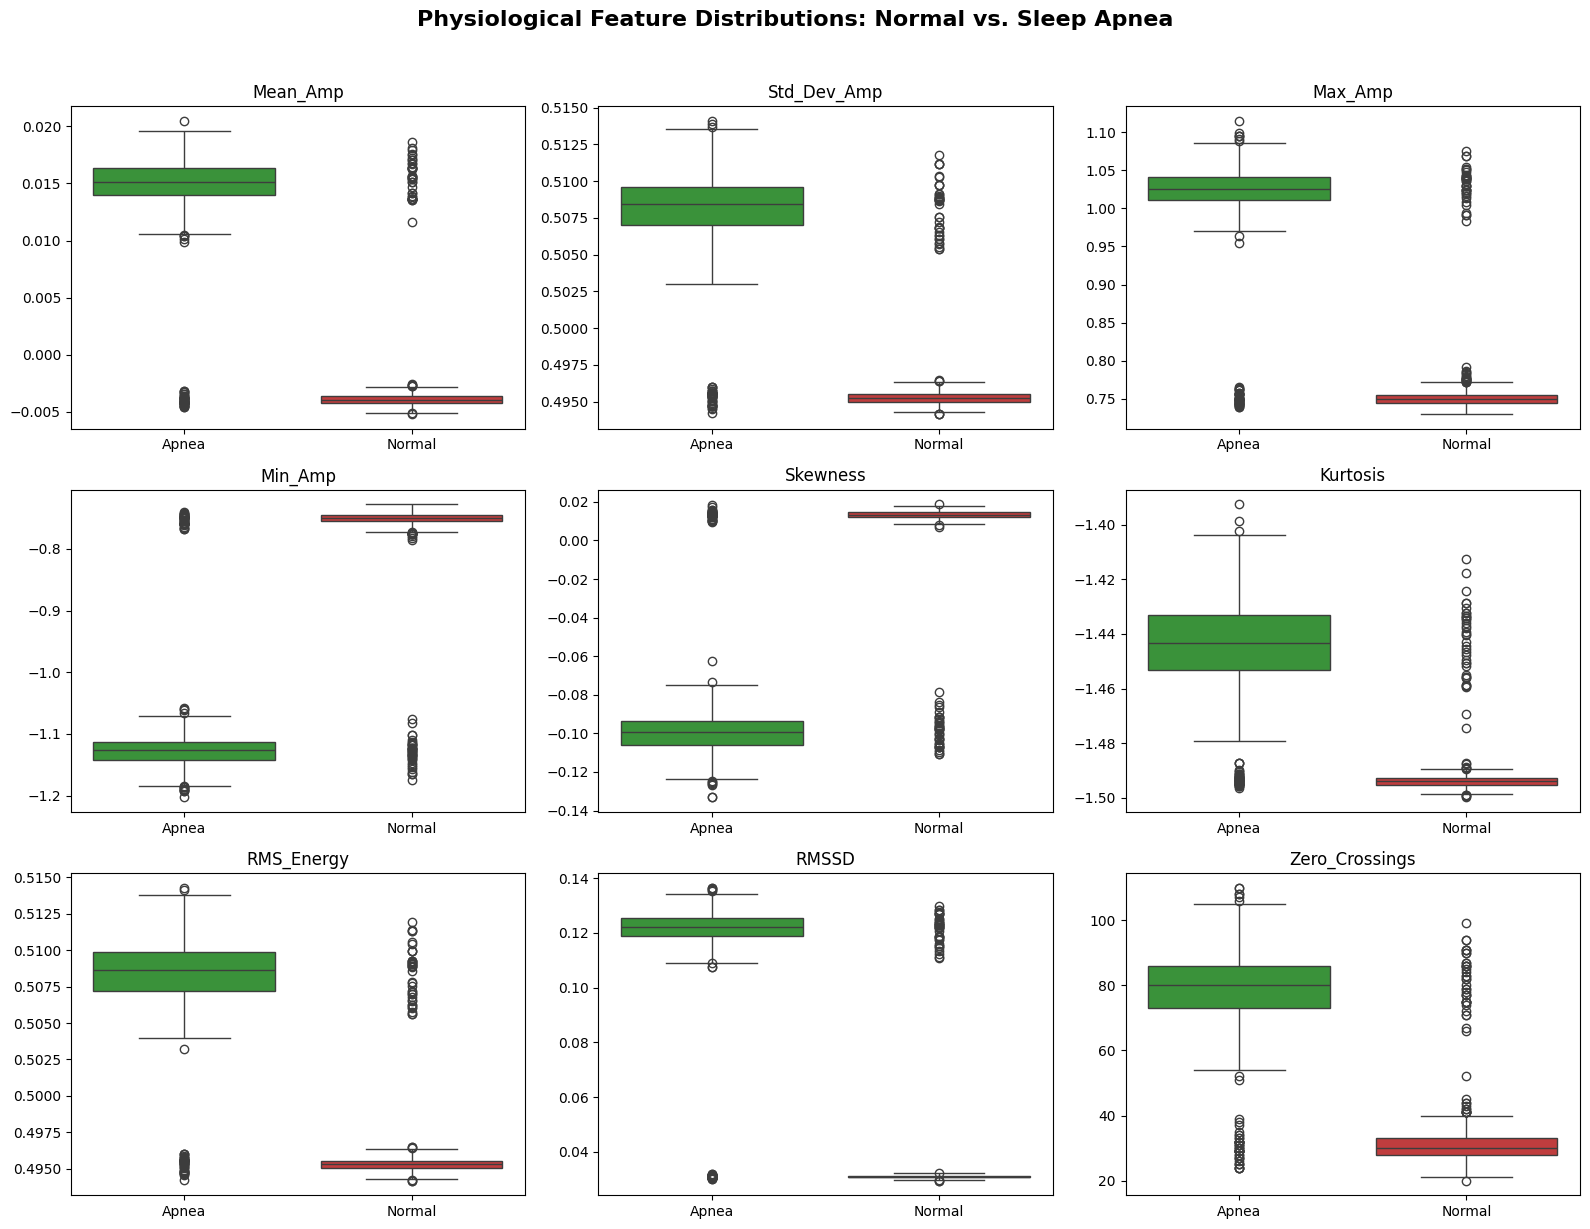

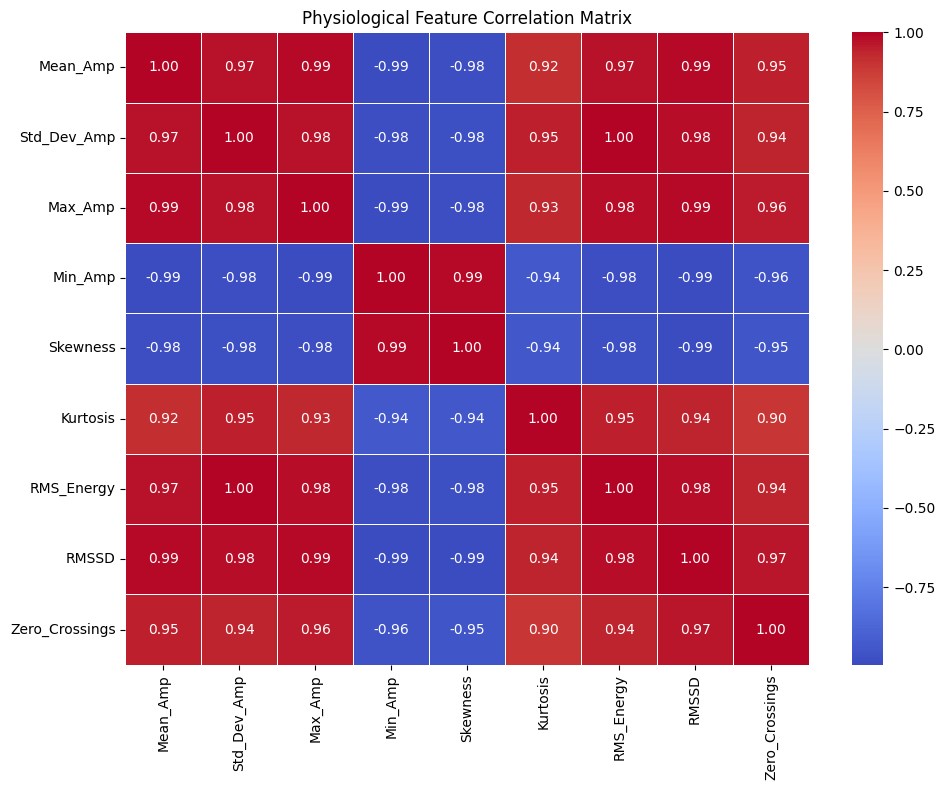

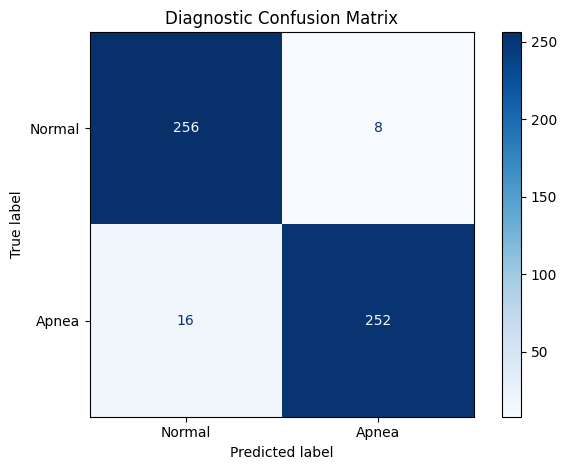

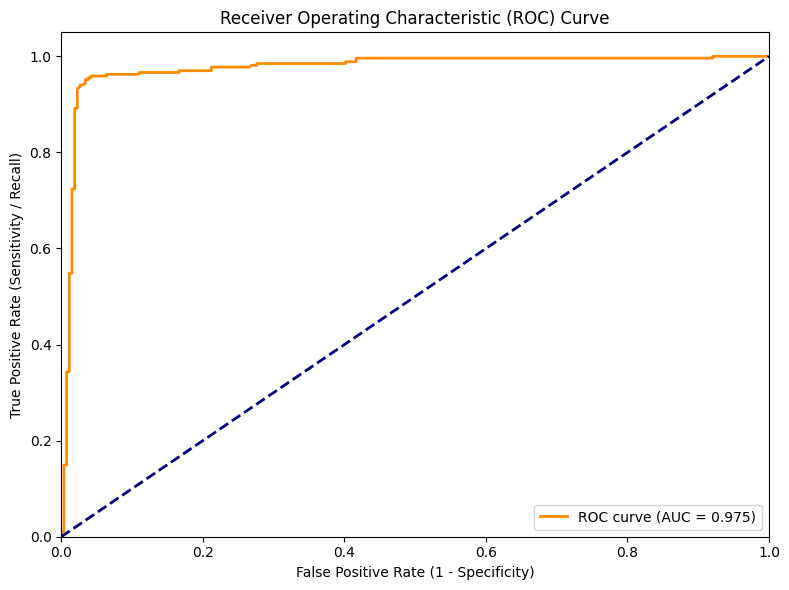

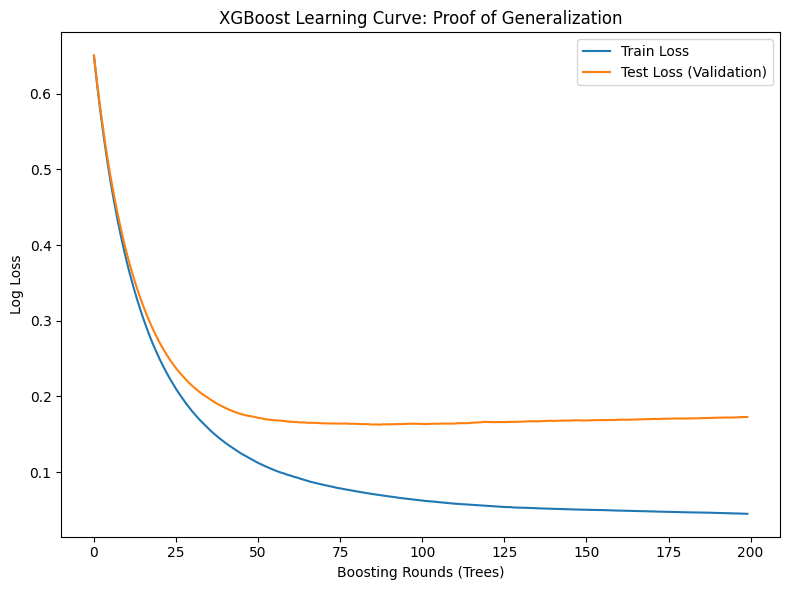

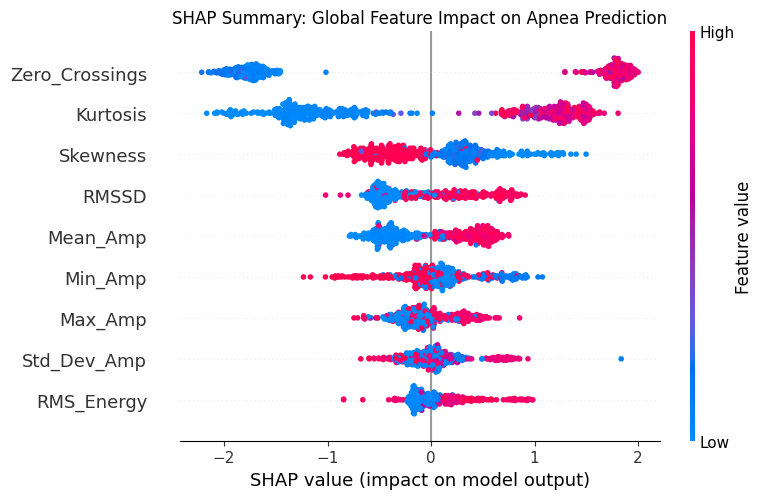

In [17]:
#Version 4
import pandas as pd
import numpy as np
import xgboost as xgb
import shap
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_curve, auc, ConfusionMatrixDisplay

def load_and_inspect_data(filepath):
    """
    Loads the CSV and separates features from the target label.
    Assuming the last column is the binary target (0 = Normal, 1 = Apnea).
    """
    print("Loading data...")
    df = pd.read_csv(filepath)
    
    # Force categorical string mapping to binary integers.
    mapping = {'Normal': 0, 'Sleep Apnea': 1}
    if 'Target' in df.columns:
        df['Target'] = df['Target'].map(mapping)
    else:
        target_col = df.columns[-1]
        df[target_col] = df[target_col].map(mapping)
        
    # Drop any rows that failed to map to maintain pipeline integrity
    df = df.dropna()
    
    # Extract features (X) and target (y)
    X_raw = df.iloc[:, :-1].values 
    y = df.iloc[:, -1].astype(int).values
    
    print(f"Data Loaded: {X_raw.shape[0]} samples, {X_raw.shape[1]} signal time-steps.")
    return X_raw, y

def extract_physiological_features(X_raw):
    """
    Transforms 3-star raw time-series data into scientifically interpretable features.
    Upgraded with RMSSD (Root Mean Square of Successive Differences) for precise vagal tone measurement.
    """
    print("Extracting interpretable physiological features...")
    features = []
    
    for signal in X_raw:
        # Time-domain morphological features
        mean_amp = np.mean(signal)
        std_amp = np.std(signal)            
        max_amp = np.max(signal)            
        min_amp = np.min(signal)            
        
        # Signal shape features 
        signal_skew = skew(signal)          
        signal_kurt = kurtosis(signal)      
        
        # Energy feature
        rms_energy = np.sqrt(np.mean(signal**2))
        
        # NEW: Advanced HRV & Frequency Proxies
        # RMSSD: Clinical gold-standard for short-term HRV (Parasympathetic activity)
        rmssd = np.sqrt(np.mean(np.diff(signal)**2))
        # Zero Crossings: Proxy for high-frequency noise or rapid morphological shifts
        zero_crossings = np.sum(np.diff(np.sign(signal)) != 0)
        
        features.append([mean_amp, std_amp, max_amp, min_amp, signal_skew, signal_kurt, rms_energy, rmssd, zero_crossings])
        
    feature_names = ['Mean_Amp', 'Std_Dev_Amp', 'Max_Amp', 'Min_Amp', 'Skewness', 'Kurtosis', 'RMS_Energy', 'RMSSD', 'Zero_Crossings']
    X_features = pd.DataFrame(features, columns=feature_names)
    
    print("Feature extraction complete.")
    return X_features

def perform_exploratory_data_analysis(X_features, y):
    """
    Conducts pre-modeling statistical comparisons and generates clinical presentation plots.
    Proves that the engineered features have distinct distributions between Normal and Apnea patients.
    """
    print("\n--- Exploratory Data Analysis (Clinical Insights) ---")
    df_eda = X_features.copy()
    df_eda['Target'] = y
    df_eda['Target_Label'] = df_eda['Target'].map({0: 'Normal', 1: 'Apnea'})
    
    # 1. Compare feature means by class
    print("Calculating feature statistics by class...")
    feature_comparison = df_eda.groupby('Target_Label').mean().drop(columns=['Target'])
    print("\nAverage Feature Values (Normal vs. Apnea):")
    print(feature_comparison.T)
    
    # Save to CSV for the final report
    feature_comparison.T.to_csv('feature_comparison_by_class.csv')
    
    # 2. Generate Boxplots for every feature
    print("Generating individual feature distribution boxplots...")
    features = X_features.columns
    fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(16, 12))
    fig.suptitle("Physiological Feature Distributions: Normal vs. Sleep Apnea", fontsize=16, fontweight='bold', y=1.02)
    axes = axes.flatten()
    
    for i, col in enumerate(features):
        # Using a clinical color palette: Green for Normal, Red for Apnea
        # WARNING FIXED: Added hue='Target_Label' and legend=False to comply with modern Seaborn syntax
        sns.boxplot(x='Target_Label', y=col, data=df_eda, ax=axes[i], hue='Target_Label', palette=['#2ca02c', '#d62728'], legend=False)
        axes[i].set_title(col, fontsize=12)
        axes[i].set_xlabel("")
        axes[i].set_ylabel("")
        
    plt.tight_layout()
    plt.savefig('feature_distributions.png', dpi=300, bbox_inches='tight')
    print("EDA complete. Analytics saved as 'feature_comparison_by_class.csv' and 'feature_distributions.png'.")

def generate_presentation_assets(X_features, y, model, X_test, y_test, evals_result):
    """
    Generates high-quality visual analytics for the 10-minute oral presentation.
    Includes an Overfitting check via Learning Curves.
    """
    print("Generating Presentation Analytics...")
    
    # 1. Feature Correlation Heatmap
    plt.figure(figsize=(10, 8))
    sns.heatmap(X_features.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
    plt.title("Physiological Feature Correlation Matrix")
    plt.tight_layout()
    plt.savefig('correlation_heatmap.png', dpi=300)
    
    # 2. Confusion Matrix
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Apnea'])
    disp.plot(cmap='Blues', values_format='d')
    plt.title("Diagnostic Confusion Matrix")
    plt.tight_layout()
    plt.savefig('confusion_matrix.png', dpi=300)

    # 3. ROC Curve & AUC
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate (1 - Specificity)')
    plt.ylabel('True Positive Rate (Sensitivity / Recall)')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.savefig('roc_curve.png', dpi=300)

    # 4. Learning Curve (Overfitting Proof)
    epochs = len(evals_result['validation_0']['logloss'])
    x_axis = range(0, epochs)
    
    plt.figure(figsize=(8, 6))
    plt.plot(x_axis, evals_result['validation_0']['logloss'], label='Train Loss')
    plt.plot(x_axis, evals_result['validation_1']['logloss'], label='Test Loss (Validation)')
    plt.legend()
    plt.ylabel('Log Loss')
    plt.xlabel('Boosting Rounds (Trees)')
    plt.title('XGBoost Learning Curve: Proof of Generalization')
    plt.tight_layout()
    plt.savefig('learning_curve.png', dpi=300)

    print("Presentation assets saved (Correlation, Confusion Matrix, ROC Curve, Learning Curve).")

def train_and_evaluate_model(X, y):
    """
    Trains XGBoost and performs K-Fold Cross Validation for rigorous academic reporting.
    Tracks validation metrics during training to plot learning curves.
    """
    print("Splitting data and training XGBoost Model...")
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    
    # Initialize XGBoost Classifier
    model = xgb.XGBClassifier(
        n_estimators=200, 
        max_depth=6, 
        learning_rate=0.05, 
        eval_metric='logloss',
        random_state=42
    )
    
    # 5-Fold Cross Validation for Model Robustness
    cv_scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')
    print(f"\n--- 5-Fold Cross-Validation ---")
    print(f"Mean CV Accuracy: {cv_scores.mean() * 100:.2f}% (Std: ±{cv_scores.std() * 100:.2f}%)")
    
    # Fit the model and track evaluation sets to prove it doesn't overfit
    eval_set = [(X_train, y_train), (X_test, y_test)]
    model.fit(X_train, y_train, eval_set=eval_set, verbose=False)
    evals_result = model.evals_result()
    
    # Predictions & Evaluation
    y_pred = model.predict(X_test)
    print("\n--- Final Test Set Performance ---")
    print(f"Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")
    print("\nClassification Report:\n", classification_report(y_test, y_pred))
    
    # Generate visual assets for the presentation, passing the learning curve data
    generate_presentation_assets(X, y, model, X_test, y_test, evals_result)
    
    return model, X_train, X_test

def apply_explainable_ai(model, X_test):
    """
    Uses SHAP to provide transparency and interpretability to the black-box model.
    """
    print("Applying SHAP (Explainable AI) analysis...")
    
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_test)
    
    print("Generating SHAP Summary Plot...")
    plt.figure(figsize=(10, 6))
    plt.title("SHAP Summary: Global Feature Impact on Apnea Prediction")
    shap.summary_plot(shap_values, X_test, show=False)
    plt.tight_layout()
    plt.savefig('shap_summary.png', dpi=300)
    
    print("SHAP analysis complete. Plot saved.")

if __name__ == "__main__":
    # UPDATE THIS PATH to your local dataset path
    DATA_PATH = 'ecg_sleep_apnea_dataset.csv'
    
    try:
        X_raw, y = load_and_inspect_data(DATA_PATH)
        X_features = extract_physiological_features(X_raw)
        
        # Run the new Exploratory Data Analysis step
        perform_exploratory_data_analysis(X_features, y)
        
        model, X_train, X_test = train_and_evaluate_model(X_features, y)
        apply_explainable_ai(model, X_test)
        print("\nPipeline Execution Successful. All assets generated for report and presentation.")
    except Exception as e:
        print(f"Error executing pipeline: {e}")
        print("Please verify the dataset path and structure.")